# Modul 1: Feature Engineering for Text Data
Modul ini membahas tentang prapemrosesan teks dan ekstraksi fitur menggunakan berbagai metode seperti Bag of Words, TF-IDF, dan Word2Vec.

In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install nltk
!pip install Sastrawi
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import os
if not os.path.exists('glove.6B.100d.txt'):
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    !unzip glove.6B.zip


pd.options.display.max_colwidth = 200
%matplotlib inline

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 9.1 MB/s eta 0:00:00ta 0:00:01
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Defaulting to user installation because normal site-packages is not writeable


## 1. Load Dataset

In [2]:
df = pd.read_csv('data/train_preprocess.csv')
df.head()

,sentence,fuel,machine,others,part,price,service
0,Saya memakai Honda Jazz GK5 tahun 2014 ( pertama meluncur ) . Mobil nya bagus dan enak sesuai moto nya menyenangkan untuk dikendarai,neutral,neutral,positive,neutral,neutral,neutral
1,Avanza kenapa jadi boros bensin begini dah ah. Baru diisi sudah mau setengah saja .,negative,neutral,neutral,neutral,neutral,neutral
2,"saran ku dan pengalaman ku , mending beli mobil niaga L300 atau canter . irit dan bandel .",positive,positive,neutral,neutral,neutral,neutral
3,Dari segi harga juga pajero lebih mahal 30 jutaan dibanding fortuner,neutral,neutral,neutral,neutral,positive,neutral
4,Kalo menurut gw enak pajero si,neutral,neutral,positive,neutral,neutral,neutral


## 2. Text Preprocessing
Melakukan normalisasi dokumen meliputi uncapitalize, penghapusan karakter non-alfabet, dan stemming menggunakan Sastrawi.

In [3]:
stemmer = StemmerFactory().create_stemmer()
wpt = nltk.WordPunctTokenizer()
stopword_factory = StopWordRemoverFactory()

def uncapitalize(doc):
    return doc.lower()

def normalize_document(doc):
    doc = uncapitalize(doc)
    # TODO: Hapus karakter non-huruf
    ################
    ##Jawab disini
    doc = re.sub(r'[^a-zA-Z\s]', ' ', doc)
    
    ################
    
    
    
    doc = doc.strip()
    
    # TODO: Tokenisasi
    ################
    # Jawab disini
    tokens = wpt.tokenize(doc)
    
    ################
    
    # Stemming
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    doc = " ".join(stemmed_tokens)
    return doc

normalize_corpus = np.vectorize(normalize_document)

norm_corpus = normalize_corpus(list(df['sentence']))
df['clean_sentence'] = norm_corpus

# Simpan hasil prapemrosesan
df.to_csv('train_preprocess_stemmed.csv', index=False)
df.head()

,sentence,fuel,machine,others,part,price,service,clean_sentence
0,Saya memakai Honda Jazz GK5 tahun 2014 ( pertama meluncur ) . Mobil nya bagus dan enak sesuai moto nya menyenangkan untuk dikendarai,neutral,neutral,positive,neutral,neutral,neutral,saya pakai honda jazz gk tahun pertama luncur mobil nya bagus dan enak sesuai moto nya senang untuk kendara
1,Avanza kenapa jadi boros bensin begini dah ah. Baru diisi sudah mau setengah saja .,negative,neutral,neutral,neutral,neutral,neutral,avanza kenapa jadi boros bensin begini dah ah baru isi sudah mau tengah saja
2,"saran ku dan pengalaman ku , mending beli mobil niaga L300 atau canter . irit dan bandel .",positive,positive,neutral,neutral,neutral,neutral,saran ku dan alam ku mending beli mobil niaga l atau canter irit dan bandel
3,Dari segi harga juga pajero lebih mahal 30 jutaan dibanding fortuner,neutral,neutral,neutral,neutral,positive,neutral,dari segi harga juga pajero lebih mahal juta banding fortuner
4,Kalo menurut gw enak pajero si,neutral,neutral,positive,neutral,neutral,neutral,kalo turut gw enak pajero si


## 3. Bag Of Words Model

Bag of word adalah teknik ekstraksi fitur dengan menghitung frekuensi kemunculan setiap kata pada dokumen.

In [4]:
from sklearn.feature_extraction.text import CountVectorizer


##TODO: Bagaimana cara menampilkan hasil matriks BoW dalam bentuk DataFrame dengan kolom sesuai dengan vocab?
##############
cv = CountVectorizer()
cv_matrix = cv.fit_transform(df['clean_sentence']).toarray()
vocab = cv.get_feature_names_out()


##############


pd.DataFrame(cv_matrix, columns=vocab).head()

,abal,abang,abis,abs,ac,accu,ada,adalah,adik,adu,...,yamahaid,yamahaindonesia,yang,yangg,yaudah,yg,ymh,yogyakarta,zaman,zr
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4. Bag of N-Grams Model (Bigram)

Bag Of N-gram adalah salah satu teknik dari Bag Of Words dengan memecah teks menjadi N kata yang berurutan. Pada modul ini kita akan menggunakan Bigram (N=2).

In [5]:

##TODO: Bagaimana cara menampilkan hasil matriks BoW dengan bigram dalam bentuk DataFrame dengan kolom sesuai dengan vocab bigram?
#################
bigram_vectorizer = CountVectorizer(ngram_range=(2,2))
bv_matrix = bigram_vectorizer.fit_transform(df['clean_sentence']).toarray()
vocab_bigram = bigram_vectorizer.get_feature_names_out()



#################


pd.DataFrame(bv_matrix, columns=vocab_bigram).head()

,abal di,abang abang,abang gue,abang naik,abis hehe,abis kalo,abs keren,ac dingin,ac enggak,ac nya,...,yg lebih,yg menang,yg paling,yg rush,yg sangat,yg tapi,ymh awat,yogyakarta dan,zaman nya,zr bukan
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 5. TF-IDF Model

TF-IDF adalah metode untuk menilai sebera penting sebuah kata terhadap suatu dokumen dalam sebuah korpus.

TF : Term Frequency, yaitu jumlah kemunculan kata dalam dokumen.

IDF : Inverse Document Frequency, yaitu mengurangi bobot kata yang muncul terlalu seting dalam dokumen dan menaikkan bobot kata yang jarang muncul tetapi spesifik untuk dokumen tertentu.

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

##TODO: Bagaimana cara menampilkan hasil matriks TF-IDF dalam bentuk DataFrame dengan kolom sesuai dengan vocab TF-IDF?
#################
tv = TfidfVectorizer()
tv_matrix = tv.fit_transform(df['clean_sentence']).toarray()
vocab_tfidf = tv.get_feature_names_out()


#################
pd.DataFrame(np.round(tv_matrix, 2), columns=vocab_tfidf).head()

,abal,abang,abis,abs,ac,accu,ada,adalah,adik,adu,...,yamahaid,yamahaindonesia,yang,yangg,yaudah,yg,ymh,yogyakarta,zaman,zr
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 6. Understanding TF-IDF from Scratch
Implementasi manual untuk menghitung TF, IDF, dan normalisasi L2.

In [43]:
from collections import Counter
import scipy.sparse as sp
from numpy.linalg import norm

# 1. Hitung Frekuensi Dokumen (DF)
unique_words = list(set([word for doc in [d.split() for d in df['clean_sentence']] for word in doc]))
def_feature_dict = {w: 0 for w in unique_words}

print(def_feature_dict)


{'manuver': 0, 'agar': 0, 'soal': 0, 'ala': 0, 'pusing': 0, 'hobi': 0, 'gari': 0, 'iip': 0, 'semua': 0, 'sepi': 0, 'hujan': 0, 'noted': 0, 'insyaallah': 0, 'kambing': 0, 'dan': 0, 'e': 0, 'besar': 0, 'sendiri': 0, 'bonceng': 0, 'mt': 0, 'kondang': 0, 'oli': 0, 'gede': 0, 'budget': 0, 'tiga': 0, 'gx': 0, 'sistem': 0, 'silinder': 0, 'macam': 0, 'faedah': 0, 'wheel': 0, 'legenda': 0, 'kehandalan': 0, 'puyeng': 0, 'not': 0, 'wuiling': 0, 'ya': 0, 'samping': 0, 'usia': 0, 'banyakin': 0, 'rusak': 0, 'juta': 0, 'bag': 0, 'tiap': 0, 'diesel': 0, 'bukti': 0, 'dapat': 0, 'ulang': 0, 'tetapi': 0, 'tua': 0, 'gigi': 0, 'selain': 0, 'bagi': 0, 'ehe': 0, 'optimal': 0, 'sz': 0, 'ubah': 0, 'kasih': 0, 'powerful': 0, 'operasional': 0, 'liter': 0, 'rembes': 0, 'gps': 0, 'suruh': 0, 'nyaman': 0, 'alias': 0, 'parking': 0, 'pernah': 0, 'walaupun': 0, 'masalah': 0, 'fun': 0, 'bodi': 0, 'jantan': 0, 'nebeng': 0, 'ketika': 0, 'biru': 0, 'buat': 0, 'bung': 0, 'sumatra': 0, 'oleh': 0, 'sanggup': 0, 'dicsitu': 0,

In [44]:
from collections import Counter
# Representasi BoW untuk setiap dokumen
bow_features = []
for doc in df['clean_sentence']:
    bow_feature = Counter(doc.split())
    all_features = Counter(def_feature_dict)
    bow_feature.update(all_features)
    bow_features.append(bow_feature)
bow_features = pd.DataFrame(bow_features)
bow_features

import scipy.sparse as sp
feature_names = list(bow_features.columns)
df_bow = np.diff(sp.csc_matrix(bow_features, dtype=int).indptr)
df_bow = 1 + df_bow

pd.DataFrame([df_bow], columns=feature_names)

,saya,pakai,honda,jazz,gk,tahun,pertama,luncur,mobil,nya,...,sporty,antar,kata,ngapain,mantap,plastik,tajam,luar,diam,abang
0,156,94,93,15,3,48,8,2,157,323,...,14,3,9,2,33,2,3,17,2,3


In [45]:
# hitung IDF
total_docs = 1 + len(df['clean_sentence'])
print(total_docs)
total_docs_float = float(total_docs)
idf = 1.0 + np.log(float(total_docs_float) / df_bow)
print(idf)
# ini adalah versi halus dari IDF
pd.DataFrame([np.round(idf, 2)], columns=feature_names)

811
[2.64841205 3.15497327 3.16566856 ... 4.86505471 7.00512087 6.59965577]


,saya,pakai,honda,jazz,gk,tahun,pertama,luncur,mobil,nya,...,sporty,antar,kata,ngapain,mantap,plastik,tajam,luar,diam,abang
0,2.65,3.15,3.17,4.99,6.6,3.83,5.62,7.01,2.64,1.92,...,5.06,6.6,5.5,7.01,4.2,7.01,6.6,4.87,7.01,6.6


In [46]:
# buat matriks diagonal IDF
total_features = bow_features.shape[1]
idf_diag = sp.spdiags(idf, diags=0, m=total_features, n=total_features)
idf_dense = idf_diag.todense()
# print the idf diagonal matrix
pd.DataFrame(np.round(idf_dense, 2))

,0,1,2,3,4,5,6,7,8,9,...,1519,1520,1521,1522,1523,1524,1525,1526,1527,1528
0,2.65,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0
1,0.00,3.15,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0
2,0.00,0.00,3.17,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0
3,0.00,0.00,0.00,4.99,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0
4,0.00,0.00,0.00,0.00,6.6,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1524,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,7.01,0.0,0.00,0.00,0.0
1525,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,6.6,0.00,0.00,0.0
1526,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,4.87,0.00,0.0
1527,0.00,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,7.01,0.0


In [47]:
# hitung TF-IDF
tf = np.array(bow_features, dtype='float64')
tfidf = tf * idf
# view raw tfidf feature matrix
pd.DataFrame(np.round(tfidf, 2), columns=feature_names)

,saya,pakai,honda,jazz,gk,tahun,pertama,luncur,mobil,nya,...,sporty,antar,kata,ngapain,mantap,plastik,tajam,luar,diam,abang
0,2.65,3.15,3.17,4.99,6.6,3.83,5.62,7.01,2.64,3.84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,2.64,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,1.92,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
806,0.00,3.15,0.00,0.00,0.0,0.00,0.00,0.00,0.00,3.84,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
807,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
808,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,1.92,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [48]:
from numpy.linalg import norm
# l2 norms
norms = norm(tfidf, axis=1)
# print norms for each document
print(np.round(norms, 3))

[19.858 19.118 20.637 12.513 11.618 18.757 20.374 11.572 19.419 21.364
 26.474 16.277 13.503 18.14  30.556 12.953 17.949 28.525 21.836 13.219
 15.246 18.959 20.207 12.98  18.768 15.121  8.781 13.165  8.179 22.729
 11.378 19.484 15.664 16.836  9.28  10.675 19.433 27.853 16.492 16.035
 18.505 13.371 16.333 14.046 18.249 23.004 18.27  11.987 23.164 13.381
 14.705 23.094 32.276 26.865 17.137 20.566 22.837 20.286 20.926 10.294
 20.156 24.678 18.56  21.868 27.035 34.358 20.092 15.979 13.841 24.563
 20.445  9.49  14.406  8.991 19.235 17.952 22.386 23.459 18.006 22.277
 12.515 22.959 17.673 17.452 12.232 19.823 13.472 12.148  8.324 24.189
 16.244 16.716 21.725 11.65  17.673 19.621 12.83  11.736 17.156 15.728
 31.879 13.675 23.951 26.071 19.217 19.673 17.243 14.401 17.159 25.973
 10.828 14.343 27.798 17.978 24.608 17.809 12.401 18.017 12.784 10.869
 14.153 16.533 12.488 13.516 16.593 30.848 16.446 10.623 15.231 20.289
 25.266 14.029  8.02  10.547 12.206 19.279 20.916 13.375 20.59  14.191
 21.24

In [49]:
norm_tfidf = tfidf / norms[:, None]
# show final tfidf feature matrix
pd.DataFrame(np.round(norm_tfidf, 2), columns=feature_names)

,saya,pakai,honda,jazz,gk,tahun,pertama,luncur,mobil,nya,...,sporty,antar,kata,ngapain,mantap,plastik,tajam,luar,diam,abang
0,0.13,0.16,0.16,0.25,0.33,0.19,0.28,0.35,0.13,0.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.13,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
805,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.12,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
806,0.00,0.22,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.27,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
807,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
808,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.09,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [50]:
new_df = pd.read_csv('data/test_preprocess.csv')
new_df.head()

,sentence,fuel,machine,others,part,price,service
0,Terios paling gagah . Apalagi warna merah metalic !,neutral,neutral,positive,positive,neutral,neutral
1,"gue pakai mobilio . menurut gue , bener fun to drive , enak dipakai nya .",neutral,neutral,positive,neutral,neutral,neutral
2,ya walaupun memiliki desain sporty kalau tingkat kenyamanan mobil berkurang juga berkurang kan,neutral,neutral,negative,positive,neutral,neutral
3,Xpander laku keras di pasar Indonesia .,neutral,neutral,positive,neutral,neutral,neutral
4,"Kalau mau segala enak pakai Avanza saja , mas .",neutral,neutral,positive,neutral,neutral,neutral


In [51]:
norm_corpus = normalize_corpus(list(new_df['sentence']))
new_df['clean_sentence'] = norm_corpus
new_df.head()

,sentence,fuel,machine,others,part,price,service,clean_sentence
0,Terios paling gagah . Apalagi warna merah metalic !,neutral,neutral,positive,positive,neutral,neutral,terios paling gagah apalagi warna merah metalic
1,"gue pakai mobilio . menurut gue , bener fun to drive , enak dipakai nya .",neutral,neutral,positive,neutral,neutral,neutral,gue pakai mobilio turut gue bener fun to drive enak pakai nya
2,ya walaupun memiliki desain sporty kalau tingkat kenyamanan mobil berkurang juga berkurang kan,neutral,neutral,negative,positive,neutral,neutral,ya walaupun milik desain sporty kalau tingkat nyaman mobil kurang juga kurang kan
3,Xpander laku keras di pasar Indonesia .,neutral,neutral,positive,neutral,neutral,neutral,xpander laku keras di pasar indonesia
4,"Kalau mau segala enak pakai Avanza saja , mas .",neutral,neutral,positive,neutral,neutral,neutral,kalau mau segala enak pakai avanza saja mas


In [52]:
pd.DataFrame(np.round(tv.transform(new_df['clean_sentence']).toarray(), 2), columns=tv.get_feature_names_out())

,abal,abang,abis,abs,ac,accu,ada,adalah,adik,adu,...,yamahaid,yamahaindonesia,yang,yangg,yaudah,yg,ymh,yogyakarta,zaman,zr
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
176,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
177,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
178,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 7. Word2Vec Model (CBOW)
Implementasi model CBOW menggunakan TensorFlow/Keras.

Word2Vec adalah model berbasis neural network yang mempelajari representasi kata dalam bentuk vector.

In [53]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import numpy as np
# Create and configure tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_sentence'])



word2id = tokenizer.word_index

# Add padding token
word2id['PAD'] = 0
id2word = {v: k for k, v in word2id.items()}
# Convert texts to sequences
wids = [[word2id[w] for w in text.split()]
        for text in df['clean_sentence']]
# Define model parameters
vocab_size = len(word2id)
embed_size = 100
window_size = 2
# Print vocabulary info
print('Vocabulary Size:', vocab_size)
print('Vocabulary Sample:', list(word2id.items())[:10])

2026-03-31 13:27:04.836996: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-31 13:27:04.882642: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-31 13:27:04.882687: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-31 13:27:04.884313: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-31 13:27:04.892578: I tensorflow/core/platform/cpu_feature_guar

Vocabulary Size: 1530
Vocabulary Sample: [('nya', 1), ('yang', 2), ('dan', 3), ('saya', 4), ('mobil', 5), ('lebih', 6), ('di', 7), ('ini', 8), ('banget', 9), ('avanza', 10)]


In [54]:
def generate_context_word_pairs(corpus, window_size, vocab_size):
    context_length = window_size * 2
    for words in corpus:
        sentence_length = len(words)
        for index, word in enumerate(words):
            context_words = []
            label_word = []
            start = index - window_size
            end = index + window_size + 1
            context_words.append(
                [
                    words[i]
                    for i in range(start, end)
                    if 0 <= i < sentence_length and i != index
                ]
            )
            label_word.append(word)
            x = pad_sequences(context_words, maxlen=context_length)
            y = to_categorical(label_word, vocab_size)
            yield (x, y)

In [55]:
i = 0
for x, y in generate_context_word_pairs(corpus=wids, window_size=window_size,vocab_size=vocab_size):
    if 0 not in x[0]:
        print('Context (X):', [id2word[w] for w in x[0]], '-> Target (Y):', id2word[np.argwhere(y[0])[0][0]])
        if i == 10:
            break
        i += 1

Context (X): ['saya', 'pakai', 'jazz', 'gk'] -> Target (Y): honda
Context (X): ['pakai', 'honda', 'gk', 'tahun'] -> Target (Y): jazz
Context (X): ['honda', 'jazz', 'tahun', 'pertama'] -> Target (Y): gk
Context (X): ['jazz', 'gk', 'pertama', 'luncur'] -> Target (Y): tahun
Context (X): ['gk', 'tahun', 'luncur', 'mobil'] -> Target (Y): pertama
Context (X): ['tahun', 'pertama', 'mobil', 'nya'] -> Target (Y): luncur
Context (X): ['pertama', 'luncur', 'nya', 'bagus'] -> Target (Y): mobil
Context (X): ['luncur', 'mobil', 'bagus', 'dan'] -> Target (Y): nya
Context (X): ['mobil', 'nya', 'dan', 'enak'] -> Target (Y): bagus
Context (X): ['nya', 'bagus', 'enak', 'sesuai'] -> Target (Y): dan
Context (X): ['bagus', 'dan', 'sesuai', 'moto'] -> Target (Y): enak


In [56]:
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Lambda

print (tf.__version__)
print(vocab_size, embed_size, window_size)
# Configure GPU memory growth


def configure_gpu():
    try:
        gpus = tf.config.list_physical_devices("GPU")
        if gpus:
            for gpu in gpus:
                # Enable memory growth for each GPU
                tf.config.experimental.set_memory_growth(gpu, True)
                print(f"Memory growth enabled for GPU: {gpu}")
        else:
            print("No GPU found, using CPU.")
    except Exception as e:
        print(f"GPU configuration error: {e}")
        print("Falling back to CPU")
        

configure_gpu()

2.15.1
1530 100 2
No GPU found, using CPU.


2026-03-31 13:27:19.929301: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [57]:
model = Sequential([
Embedding(input_dim=vocab_size, output_dim=embed_size,
          input_length=(window_size * 2)),
Lambda(lambda x: K.mean(x, axis=1), output_shape=(embed_size,)),
Dense(vocab_size, activation='softmax')
])
model.build(input_shape=(None, window_size * 2))
model.compile(loss='categorical_crossentropy', optimizer='rmsprop')

In [58]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 4, 100)            153000    
                                                                 
 lambda (Lambda)             (None, 100)               0         
                                                                 
 dense (Dense)               (None, 1530)              154530    
                                                                 
Total params: 307530 (1.17 MB)
Trainable params: 307530 (1.17 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
for epoch in range(1, 6):
    loss = 0.
    i = 0
    for x, y in generate_context_word_pairs(corpus=wids,window_size=window_size, vocab_size=vocab_size):
        i += 1
        loss += model.train_on_batch(x, y)
        if i % 100000 == 0:
            print('Processed {} (context, word) pairs'.format(i))
        print('Epoch:', epoch, '\tLoss:', loss)
        print()

Epoch: 1 	Loss: 3.397002696990967

Epoch: 1 	Loss: 8.478556156158447

Epoch: 1 	Loss: 12.706133365631104

Epoch: 1 	Loss: 20.218510150909424

Epoch: 1 	Loss: 28.019874095916748

Epoch: 1 	Loss: 35.86119222640991

Epoch: 1 	Loss: 43.474180698394775

Epoch: 1 	Loss: 50.82910108566284

Epoch: 1 	Loss: 55.28438854217529

Epoch: 1 	Loss: 58.70401692390442

Epoch: 1 	Loss: 65.43974566459656

Epoch: 1 	Loss: 68.34332394599915

Epoch: 1 	Loss: 74.66286396980286

Epoch: 1 	Loss: 82.40028023719788

Epoch: 1 	Loss: 90.54275918006897

Epoch: 1 	Loss: 93.3659975528717

Epoch: 1 	Loss: 100.67930197715759

Epoch: 1 	Loss: 106.72814202308655

Epoch: 1 	Loss: 113.77521014213562

Epoch: 1 	Loss: 120.26014351844788

Epoch: 1 	Loss: 127.32325053215027

Epoch: 1 	Loss: 134.30021357536316

Epoch: 1 	Loss: 141.26112532615662

Epoch: 1 	Loss: 148.22935271263123

Epoch: 1 	Loss: 156.28647780418396

Epoch: 1 	Loss: 164.37026953697205

Epoch: 1 	Loss: 171.77456498146057

Epoch: 1 	Loss: 178.61176991462708

Epoch

In [63]:
weights = model.get_weights()[0]
weights = weights[1:]
print(weights.shape)
pd.DataFrame(weights, index=list(id2word.values())[1:]).head()

(1529, 100)


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
yang,0.284916,0.067300,-0.257435,0.277997,-0.343027,-0.348492,0.051981,-0.211882,0.269341,-0.132901,...,-0.163370,-0.261807,0.337659,0.350970,-0.029071,-0.379536,0.069616,0.036053,-0.216133,0.233963
dan,0.364501,0.100414,0.595732,0.048878,0.008742,0.120697,0.037584,-0.093775,-0.139224,-0.244428,...,-0.038889,-0.149995,-0.055896,0.070533,-0.119124,-0.183758,-0.076650,-0.076766,0.274073,0.158815
saya,0.529536,0.160587,0.172157,0.333336,-0.154888,-0.231407,0.253168,-0.193919,-0.155986,0.106992,...,0.179781,0.385069,0.111793,0.192116,-0.243281,-0.160297,0.306308,0.004795,0.373987,0.114354
mobil,0.188744,0.238141,0.440548,-0.259401,0.168130,0.122983,-0.053548,0.156798,-0.161606,0.226215,...,0.250044,0.125214,-0.345021,-0.492530,0.052119,0.013173,-0.104574,0.238844,0.254516,0.240772
lebih,0.370537,-0.198448,-0.140836,-0.187868,0.087368,0.030630,0.285983,0.046867,-0.029840,0.344861,...,0.163850,-0.011494,-0.239910,0.146722,0.470824,-0.034420,-0.026777,-0.205607,0.148733,0.076084


## 8. Gensim Word2Vec
Menggunakan library Gensim untuk melihat kemiripan kata (semantic similarity).

In [64]:
from gensim.models import Word2Vec
import nltk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# tokenize sentences in corpus
wpt = nltk.WordPunctTokenizer()
df = pd.read_csv("train_preprocess_stemmed.csv")

## TODO: bagaimana cara melakukan tokenisasi pada setiap kalimat dalam kolom "clean_sentence" dan menyimpan hasilnya dalam variabel tokenized_corpus?

###################
tokenized_corpus = [wpt.tokenize(str(sentence)) for sentence in df["clean_sentence"]]


##################
print(tokenized_corpus)

feature_size = 1000
window_context = 30  # Context window size
min_word_count = 1  # Minimum word count
sample = 1e-3

w2v_model = Word2Vec(
    sentences=tokenized_corpus,  
    vector_size=feature_size,  
    window=window_context,  
    min_count=min_word_count,  
    sample=sample,  
    workers=8,  
)

similar_words = {
    search_term: [item[0]
                  for item in w2v_model.wv.most_similar([search_term], topn=5)]
    for search_term in [
        "avanza",
        "mobil",
        "toyota",
        "bagus",
        "kijang",
    ]
}
similar_words

[['saya', 'pakai', 'honda', 'jazz', 'gk', 'tahun', 'pertama', 'luncur', 'mobil', 'nya', 'bagus', 'dan', 'enak', 'sesuai', 'moto', 'nya', 'senang', 'untuk', 'kendara'], ['avanza', 'kenapa', 'jadi', 'boros', 'bensin', 'begini', 'dah', 'ah', 'baru', 'isi', 'sudah', 'mau', 'tengah', 'saja'], ['saran', 'ku', 'dan', 'alam', 'ku', 'mending', 'beli', 'mobil', 'niaga', 'l', 'atau', 'canter', 'irit', 'dan', 'bandel'], ['dari', 'segi', 'harga', 'juga', 'pajero', 'lebih', 'mahal', 'juta', 'banding', 'fortuner'], ['kalo', 'turut', 'gw', 'enak', 'pajero', 'si'], ['ch', 'r', 'versi', 'negara', 'ini', 'kurang', 'worth', 'it', 'soal', 'fitur', 'dan', 'lengkap'], ['linaradj', 'kapan', 'kapan', 'coba', 'bengkel', 'daihatsu', 'mereka', 'mau', 'kok', 'servis', 'lebih', 'bagus'], ['mending', 'confero', 'harga', 'nya', 'lebih', 'murah', 'daripada', 'formo'], ['kalo', 'soal', 'servis', 'mending', 'pilih', 'grand', 'livina', 'soal', 'after', 'sales', 'service', 'nya', 'mudah', 'dan', 'cepat'], ['lampu', 'utama

{'avanza': ['nya', 'yang', 'dan', 'di', 'honda'],
 'mobil': ['nya', 'saya', 'yang', 'honda', 'dan'],
 'toyota': ['nya', 'dan', 'honda', 'yang', 'saya'],
 'bagus': ['nya', 'dan', 'honda', 'saya', 'yang'],
 'kijang': ['mahal', 'dengan', 'tidak', 'buat', 'saja']}

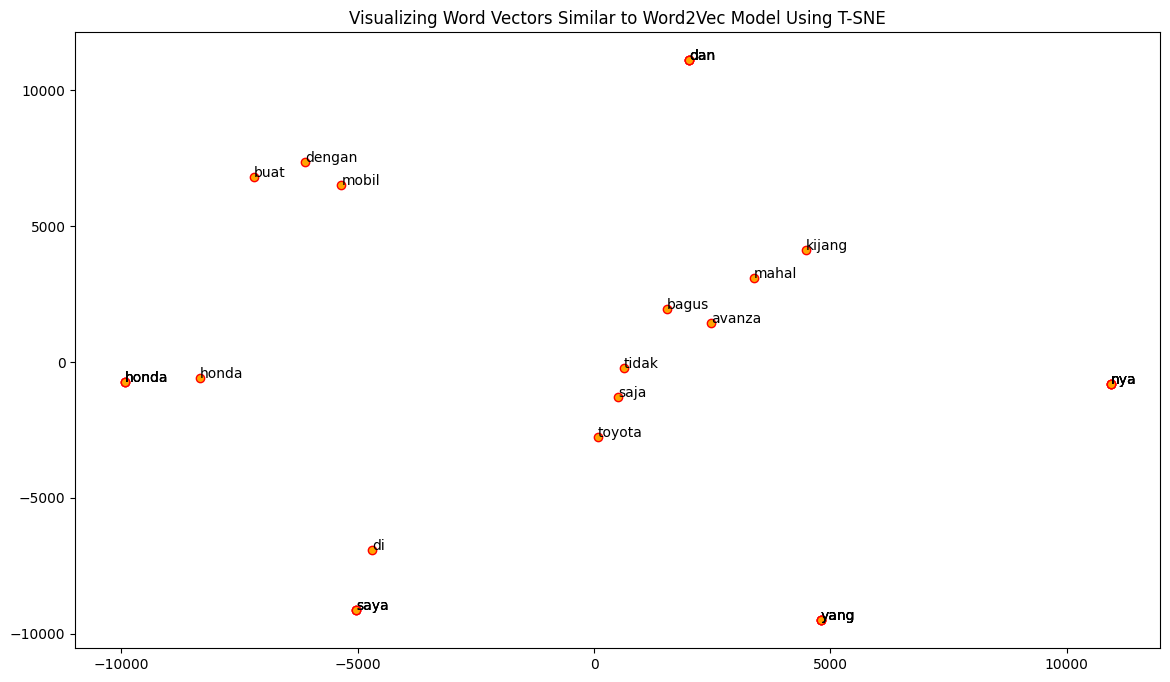

In [65]:
from sklearn.manifold import TSNE
words = sum([[k] + v for k, v in similar_words.items()], [])
wvs = w2v_model.wv[words]

tsne = TSNE(n_components=2, random_state=0, max_iter=10000, perplexity=2)
np.set_printoptions(suppress=True)
T = tsne.fit_transform(wvs)
labels = words
plt.figure(figsize=(14, 8))
plt.title("Visualizing Word Vectors Similar to Word2Vec Model Using T-SNE")
plt.scatter(T[:, 0], T[:, 1], c="orange", edgecolors="r")
for label, x, y in zip(labels, T[:, 0], T[:, 1]):
    plt.annotate(label, xy=(x + 1, y + 1), xytext=(0, 0), textcoords="offset points")

In [66]:
w2v_model.wv["avanza"]

array([ 0.15913107,  0.05934138,  0.04341648,  0.1019915 , -0.04494692,
       -0.01103585,  0.00755982,  0.10131022, -0.053714  ,  0.02638814,
        0.03577007,  0.00255367,  0.00461493,  0.05081115,  0.08871114,
       -0.0385704 , -0.07024305, -0.00536902,  0.03990731, -0.16641153,
        0.06115875, -0.08606686, -0.00134105, -0.03383565,  0.0703034 ,
       -0.04817225,  0.03958819, -0.0135418 , -0.20844272,  0.06396505,
        0.06849869, -0.10614788,  0.00794818, -0.07191173,  0.08561305,
       -0.04755411,  0.06113723, -0.00057792, -0.05250613, -0.13513957,
       -0.05613355,  0.04342911, -0.10692652,  0.12827575, -0.01581203,
       -0.03312549, -0.04992971,  0.1337698 , -0.07338814,  0.08255785,
        0.00641219, -0.02774426, -0.03750883, -0.09501596,  0.03539312,
        0.00521865,  0.09116662, -0.04544497, -0.07843493, -0.02991332,
       -0.08155604, -0.01700115, -0.0900497 ,  0.03336138, -0.03058888,
        0.09285362, -0.02160777,  0.15005234,  0.02750566, -0.01

In [67]:
import spacy
## instll tar.gz
glove_file = open(
    ##TODO: Bagaimana cara membuka file GloVe yang sudah diunduh"?
    "glove.6B.100d.txt", encoding="utf-8"
    )

embedding_index = dict()
for line in glove_file:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype="float32")
    embedding_index[word] = coefs
glove_file.close()
print("Found %s word vectors." % len(embedding_index))
# create embedding matrix
embeddiing_matrix = np.zeros((len(word2id) + 1, embed_size))
for word, i in word2id.items():
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embeddiing_matrix[i] = embedding_vector
print(embeddiing_matrix.shape)

Found 400000 word vectors.
(1531, 100)


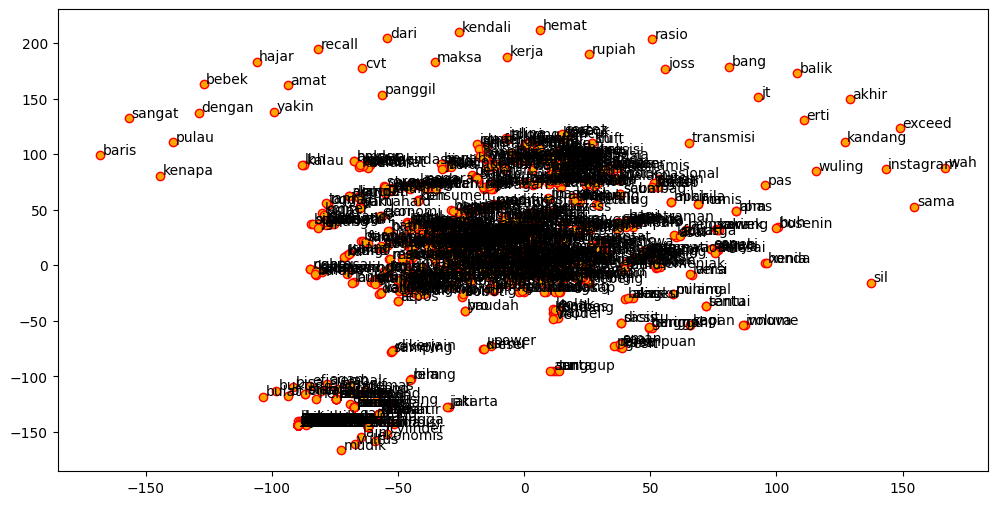

In [74]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0, max_iter=5000, perplexity=3)
np.set_printoptions(suppress=True)
#TODO: Bagaimana cara melakukan transformasi T-SNE pada embedding matrix untuk mendapatkan representasi 2D dari vektor kata?
T = tsne.fit_transform(embeddiing_matrix[1:len(unique_words)+1])
labels = unique_words

plt.figure(figsize=(12, 6))
plt.scatter(T[:, 0], T[:, 1], c="orange", edgecolors="r")
for label, x, y in zip(labels, T[:, 0], T[:, 1]):
    plt.annotate(label, xy=(x + 1, y + 1), xytext=(0, 0), textcoords="offset points")

,sentence,fuel,machine,others,part,price,service,clean_sentence,ClusterLabel
0,Saya memakai Honda Jazz GK5 tahun 2014 ( pertama meluncur ) . Mobil nya bagus dan enak sesuai moto nya menyenangkan untuk dikendarai,neutral,neutral,positive,neutral,neutral,neutral,saya pakai honda jazz gk tahun pertama luncur mobil nya bagus dan enak sesuai moto nya senang untuk kendara,2
1,Avanza kenapa jadi boros bensin begini dah ah. Baru diisi sudah mau setengah saja .,negative,neutral,neutral,neutral,neutral,neutral,avanza kenapa jadi boros bensin begini dah ah baru isi sudah mau tengah saja,0
2,"saran ku dan pengalaman ku , mending beli mobil niaga L300 atau canter . irit dan bandel .",positive,positive,neutral,neutral,neutral,neutral,saran ku dan alam ku mending beli mobil niaga l atau canter irit dan bandel,2
3,Dari segi harga juga pajero lebih mahal 30 jutaan dibanding fortuner,neutral,neutral,neutral,neutral,positive,neutral,dari segi harga juga pajero lebih mahal juta banding fortuner,0
4,Kalo menurut gw enak pajero si,neutral,neutral,positive,neutral,neutral,neutral,kalo turut gw enak pajero si,0
...,...,...,...,...,...,...,...,...,...
805,Naik pajero goyang nya parah mending naik inova,neutral,neutral,positive,neutral,neutral,neutral,naik pajero goyang nya parah mending naik inova,0
806,pengalaman berkendara nya sangat menyenangkan pakai Avanza karena suara mesin nya yang halus,neutral,positive,neutral,neutral,neutral,neutral,alam kendara nya sangat senang pakai avanza karena suara mesin nya yang halus,0
807,"agya agak sedikit mengecewakan, gak bagus",neutral,neutral,negative,neutral,neutral,neutral,agya agak sedikit kecewa gak bagus,0
808,Di samping harga nya yang terjangkau motor matic vario irit bahan bakar dan nyaman untuk digunakan dalam melaksanakan kegiatan sehari-hari .,positive,neutral,positive,neutral,positive,neutral,di samping harga nya yang jangkau motor matic vario irit bahan bakar dan nyaman untuk guna dalam laksana giat hari hari,2


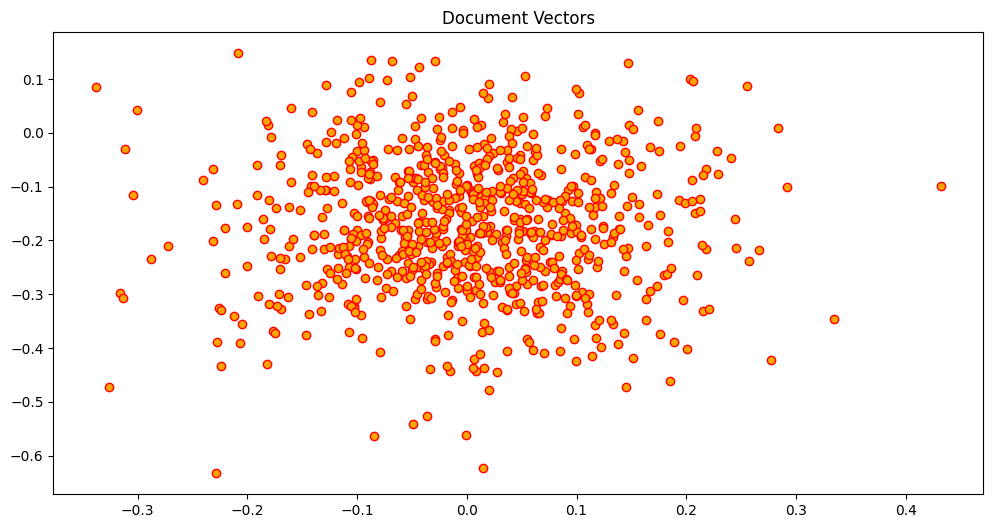

In [75]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
doc_glove_vectors = np.array(
    [np.mean([embeddiing_matrix[word2id[w]] for w in doc.split()
             if w in word2id], axis=0) for doc in df['clean_sentence']]
)
doc_glove_vectors.shape
plt.figure(figsize=(12, 6))
plt.scatter(doc_glove_vectors[:, 0],
            doc_glove_vectors[:, 1], c="orange", edgecolors="r")
plt.title("Document Vectors")
km = KMeans(n_clusters=3, random_state=0)
km.fit_transform(doc_glove_vectors)
cluster_labels = km.labels_
cluster_labels = pd.DataFrame(cluster_labels, columns=["ClusterLabel"])
pd.concat([df, cluster_labels], axis=1)

## Glove from Spacy ID Nusantara

In [77]:
import spacy

## TODO: Bila belum terinstall id nusantara, coba cari tahu bagaimana cara menginstall id nusantara dan cara memuat model id nusantara dengan spacy
!pip install "id_nusantara-1.1.tar.gz"
!python -m pip install jupyterlab ipywidgets
# for JupyterLab < 3:
!python -m jupyter labextension install @jupyter-widgets/jupyterlab-manager

## TODO: Load Model spacy dengan id nusantara
nlp = spacy.load("id_nusantara")

############

############

unique_words = list(
    set([word for sublist in [doc.split()
                              for doc in df["clean_sentence"]] for word in sublist])
)
word_glove_vectors = np.array([nlp(word).vector for word in unique_words])
pd.DataFrame(word_glove_vectors, index=unique_words)

Defaulting to user installation because normal site-packages is not writeable
Processing ./id_nusantara-1.1.tar.gz
  Preparing metadata (setup.py) ... done
  Created wheel for id_nusantara: filename=id_nusantara-1.1-py3-none-any.whl size=8244119 sha256=54eac9b5313163b5659189ef670c14e6bfdf680dd58338ca3682021336c7c415
  Stored in directory: /home/jupyter-230712298/.cache/pip/wheels/9c/b8/e7/3d14f23e0751a7afc2af5d319b9ec7644f339f992540ed470a
Successfully built id_nusantara
  Attempting uninstall: id_nusantara
    Found existing installation: id_nusantara 1.1
    Uninstalling id_nusantara-1.1:
      Successfully uninstalled id_nusantara-1.1
Defaulting to user installation because normal site-packages is not writeable
(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be removed in a future major version of JupyterLab.

Users should manage prebuilt extensions with package managers like pip and conda, and extension authors are encourag

,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
manuver,-4.226807,2.478498,-3.141151,-3.090372,-0.466774,-0.256498,1.547071,3.949317,1.046534,-2.584695,...,-1.743988,-2.138082,-5.162778,-2.811503,-3.568411,4.409525,-3.725912,-2.020272,3.245975,-0.467461
agar,1.726361,-3.824710,-0.948234,4.176501,2.242874,3.352923,0.870891,-0.322794,5.257199,-3.992762,...,1.057471,-2.382466,-1.921206,-4.585259,-1.262177,-1.213981,-3.626061,0.711391,1.681473,-3.817778
soal,-1.580375,0.384516,2.005800,0.360736,2.698098,2.753661,-2.502816,-1.778622,2.180211,-1.802146,...,-0.460035,-1.144641,-0.787992,3.424174,-4.518000,4.471284,0.327311,-0.854425,6.522592,-2.120891
ala,-1.728018,1.136143,0.456727,-1.879300,-0.155563,-0.063872,-1.702850,2.586177,2.279766,-2.965526,...,-1.266884,-4.477833,-1.202528,2.332468,-3.011121,5.585082,-2.075745,-2.810328,3.929692,1.153217
pusing,-1.511088,-0.615267,-1.051872,-1.295829,2.090985,-1.143062,-1.502803,2.953026,0.623195,-2.072849,...,-1.563843,-4.390392,-4.466787,2.086647,-1.435393,0.666981,-1.197707,-1.985321,3.172374,2.037996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
plastik,-3.972211,-0.759196,2.135016,-2.288056,2.992536,1.220349,-4.321264,0.218729,-1.816174,-1.706300,...,-1.182301,-1.433232,1.101227,2.668112,-1.103271,4.632727,-1.922870,-1.875087,2.831966,0.887016
tajam,-0.261629,-4.574778,-1.049580,-1.711371,7.613427,2.573118,-0.264418,-2.161098,-2.822958,1.431746,...,-3.299954,-5.509618,-1.363729,2.330056,-4.171162,1.205845,3.722877,-0.073725,-2.903224,-1.933657
luar,0.596942,1.810274,0.906930,1.847665,2.320920,5.265163,0.890743,-0.946243,-0.369146,1.178975,...,-1.091796,-1.904268,-1.055041,3.520595,-3.812601,3.650521,-1.381701,-1.353137,-0.396131,0.231663
diam,0.119136,0.870369,1.045083,1.045838,-0.474503,1.820302,7.199185,3.029911,-2.061426,4.419784,...,-1.557228,-4.986384,-0.578982,3.367494,-9.347279,1.752204,-0.150460,-2.678284,0.210217,0.252142


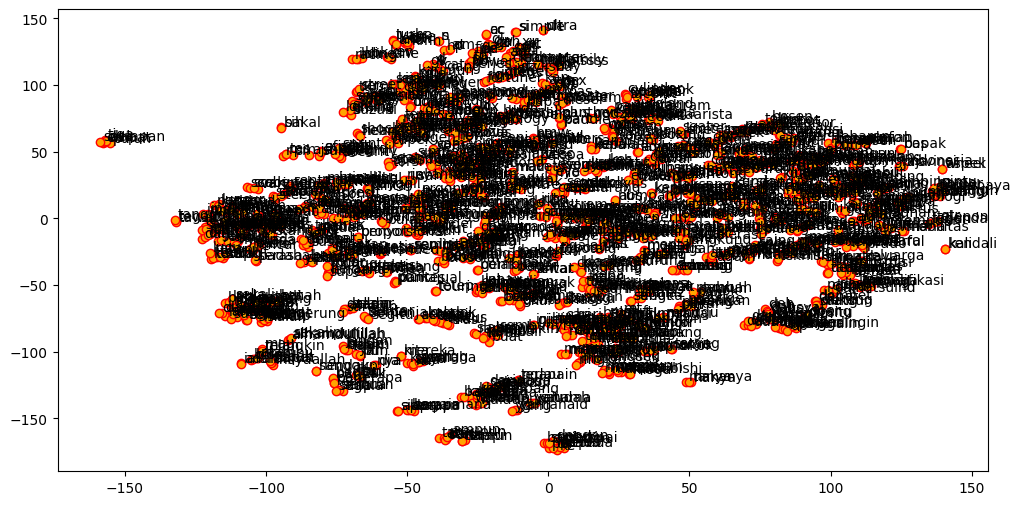

In [78]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0, max_iter=5000, perplexity=3)
np.set_printoptions(suppress=True)
T = tsne.fit_transform(word_glove_vectors)
labels = unique_words
plt.figure(figsize=(12, 6))
plt.scatter(T[:, 0], T[:, 1], c="orange", edgecolors="r")
for label, x, y in zip(labels, T[:, 0], T[:, 1]):
    plt.annotate(label, xy=(x + 1, y + 1), xytext=(0, 0), textcoords="offset points")

In [79]:
doc_glove_vectors = np.array(
    [nlp(str(doc)).vector for doc in df["clean_sentence"]])
km = KMeans(n_clusters=3, random_state=0)
km.fit_transform(doc_glove_vectors)
cluster_labels = km.labels_
cluster_labels = pd.DataFrame(cluster_labels, columns=["ClusterLabel"])
pd.concat([df, cluster_labels], axis=1)

,sentence,fuel,machine,others,part,price,service,clean_sentence,ClusterLabel
0,Saya memakai Honda Jazz GK5 tahun 2014 ( pertama meluncur ) . Mobil nya bagus dan enak sesuai moto nya menyenangkan untuk dikendarai,neutral,neutral,positive,neutral,neutral,neutral,saya pakai honda jazz gk tahun pertama luncur mobil nya bagus dan enak sesuai moto nya senang untuk kendara,1
1,Avanza kenapa jadi boros bensin begini dah ah. Baru diisi sudah mau setengah saja .,negative,neutral,neutral,neutral,neutral,neutral,avanza kenapa jadi boros bensin begini dah ah baru isi sudah mau tengah saja,2
2,"saran ku dan pengalaman ku , mending beli mobil niaga L300 atau canter . irit dan bandel .",positive,positive,neutral,neutral,neutral,neutral,saran ku dan alam ku mending beli mobil niaga l atau canter irit dan bandel,1
3,Dari segi harga juga pajero lebih mahal 30 jutaan dibanding fortuner,neutral,neutral,neutral,neutral,positive,neutral,dari segi harga juga pajero lebih mahal juta banding fortuner,2
4,Kalo menurut gw enak pajero si,neutral,neutral,positive,neutral,neutral,neutral,kalo turut gw enak pajero si,0
...,...,...,...,...,...,...,...,...,...
805,Naik pajero goyang nya parah mending naik inova,neutral,neutral,positive,neutral,neutral,neutral,naik pajero goyang nya parah mending naik inova,0
806,pengalaman berkendara nya sangat menyenangkan pakai Avanza karena suara mesin nya yang halus,neutral,positive,neutral,neutral,neutral,neutral,alam kendara nya sangat senang pakai avanza karena suara mesin nya yang halus,2
807,"agya agak sedikit mengecewakan, gak bagus",neutral,neutral,negative,neutral,neutral,neutral,agya agak sedikit kecewa gak bagus,0
808,Di samping harga nya yang terjangkau motor matic vario irit bahan bakar dan nyaman untuk digunakan dalam melaksanakan kegiatan sehari-hari .,positive,neutral,positive,neutral,positive,neutral,di samping harga nya yang jangkau motor matic vario irit bahan bakar dan nyaman untuk guna dalam laksana giat hari hari,2


In [80]:
from gensim.models.fasttext import FastText
## TODO: Bagaimana cara membuat objek WordPunctTokenizer dari nltk untuk melakukan tokenisasi pada setiap kalimat dalam kolom "clean_sentence"?
wpt = nltk.WordPunctTokenizer()
tokenized_corpus = [wpt.tokenize(document)
                    for document in df["clean_sentence"]]
feature_size = 100
window_context = 50
min_word_count = 5
sample = 1e-3
ft_model = FastText(
    sentences=tokenized_corpus,
    vector_size=feature_size,
    window=window_context,
    min_count=min_word_count,
    sample=sample,
    epochs=50,
)

In [81]:
similar_words = {
search_term: [item[0] for item in ft_model.wv.most_similar([search_term], topn=5)]
for search_term in ["avanza",
"mobil",
"toyota",
"bagus",
"kijang",
]
}
similar_words

{'avanza': ['juga', 'tampil', 'stabil', 'bagi', 'bagai'],
 'mobil': ['l', 'kijang', 'kecil', 'milik', 's'],
 'toyota': ['semua', 'rata', 'daihatsu', 'yamaha', 'ramah'],
 'bagus': ['onderdil', 'bakal', 'bikin', 'banyak', 'tentu'],
 'kijang': ['milik', 'kuat', 'innova', 'hanya', 'aman']}

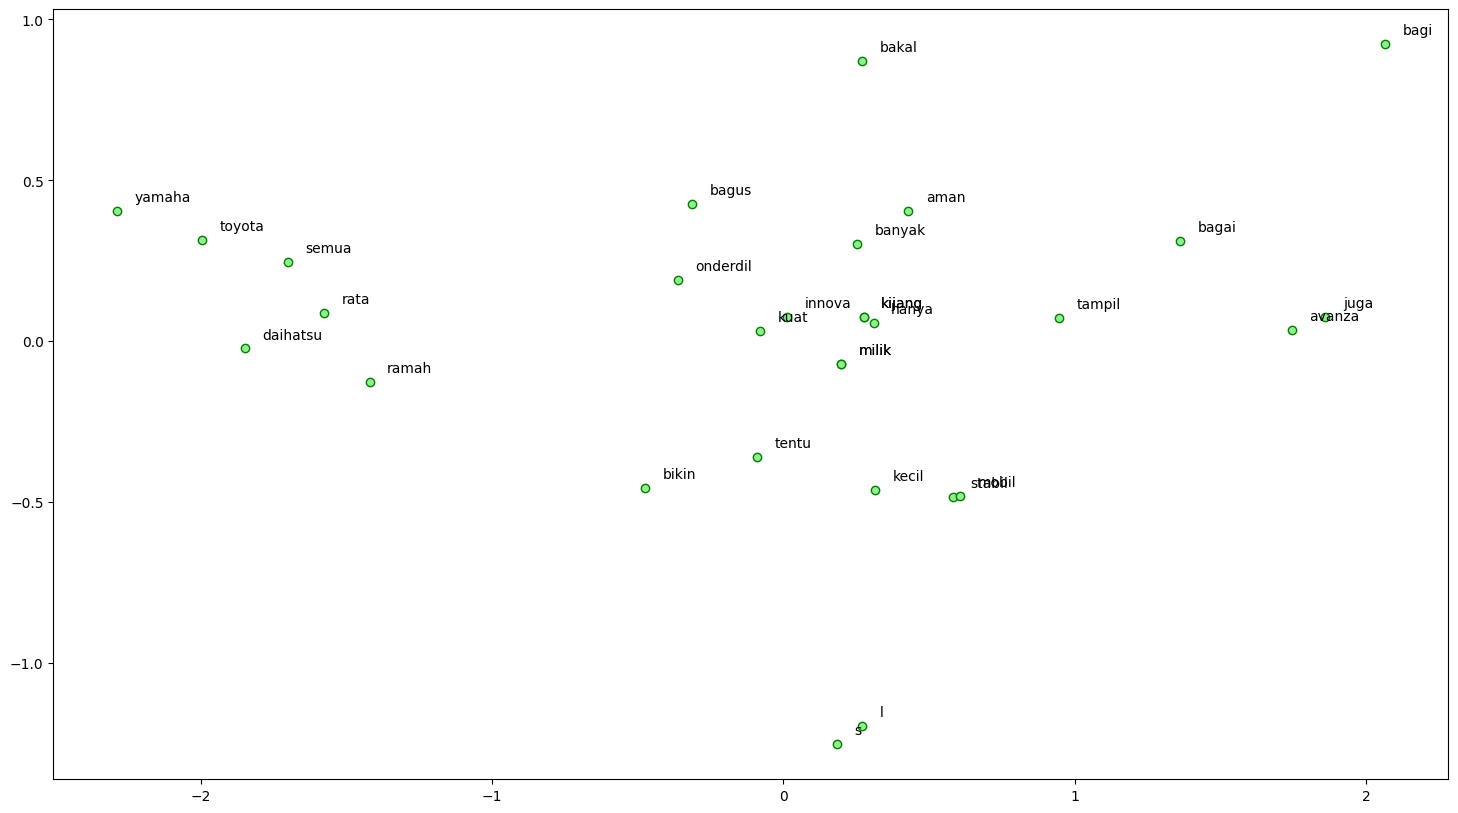

In [82]:
from sklearn.decomposition import PCA
words = sum([[k] + v for k, v in similar_words.items()], [])
wvs = ft_model.wv[words]
pca = PCA(n_components=2)
np.set_printoptions(suppress=True)
P = pca.fit_transform(wvs)
labels = words
plt.figure(figsize=(18, 10))
plt.scatter(P[:, 0], P[:, 1], c="lightgreen", edgecolors="g")
for label, x, y in zip(labels, P[:, 0], P[:, 1]):
    plt.annotate(label, xy=(x + 0.06, y + 0.03), xytext=(0, 0), textcoords="offset points"
    )

In [83]:
ft_model.wv["avanza"]

array([-0.50699025,  0.13248974, -0.11906773,  0.15481986,  0.25179458,
       -0.00809813,  0.4067111 , -0.10612442,  0.21974711,  0.40547413,
       -0.14158772, -0.20266147, -0.42811665,  0.03071432, -0.6458573 ,
        0.13107103,  0.6062916 , -0.06051448, -0.27819481, -0.47058302,
       -0.28157973, -0.25385118, -0.3251515 ,  0.2501345 , -0.18666743,
       -0.19827513, -0.25646913,  0.03069534, -0.14481325,  0.35574937,
        0.05039513,  0.24896182,  0.12996478, -0.22927886,  0.05559835,
        0.1579175 ,  0.2573362 ,  0.08260952, -0.20804442, -0.08402402,
       -0.29989848,  0.23685709, -0.00726886,  0.6403137 ,  0.32859448,
        0.06718916, -0.50471514, -0.2599768 , -0.31309852, -0.05435209,
       -0.14387396,  0.19786172, -0.18632719,  0.08457261, -0.02159383,
        0.24380529, -0.06773737,  0.06582265,  0.22016871,  0.19439352,
        0.6034103 , -0.23233755, -0.26514336, -0.07581637, -0.47766003,
        0.16057177,  0.4819126 ,  0.2699937 ,  0.305838  ,  0.15

In [84]:
print(ft_model.wv.similarity(w1="avanza", w2="toyota"))
print(ft_model.wv.similarity(w1="kijang", w2="toyota"))

0.124010935
0.53451586


In [85]:
st1 = "kijang avanza spacy"
st2 = "mobil toyota sangat bagus"
st3 = "mobil avanza sangat murah"
print("kata berbeda[", st1, "]:", ft_model.wv.doesnt_match(st1.split()))

kata berbeda[ kijang avanza spacy ]: spacy
